In [1]:
ENV["PYTHONPATH"] = "/home/gridsan/aligho/.local/lib/python3.8/site-packages/PyNormaliz-2.15-py3.8-linux-x86_64.egg";

In [2]:
using DelimitedFiles, PyPlot, LinearAlgebra
using Crystalline, Brillouin, MPBUtils, SymmetryBases
using Crystalline: TEST_αβγs, TEST_αβγ, dot, norm
topology_paper_dir = "../TopologyPaper/"
include(topology_paper_dir * "get-freqs-symeigs.jl")
include(topology_paper_dir * "symeigs-from-io.jl");

In [6]:
dir = "./defect_scan/"
supercell = 5 # 5x5x5 supercell
resolution = 16
num_bands = 300
m = 20 

dispersions = zeros((m, num_bands))
for n in 1:20
    filename = "supercell-$n-$m-$supercell-$resolution.log"
    io = open(dir * filename)
    logstr = read(io, String)
    close(io)
    dispersion_str = logs_to_dispersion(logstr, "");
    dispersion = readdlm(IOBuffer(dispersion_str), ',')[:, 6:end]
    dispersions[n, :] = dispersion
end
delta = 0.0005 # Window over which we check for degeneracy 
y_coords = [(0.34 + delta*(delta_idx+0.5)) for delta_idx in 0:50]
num_states = [[count(x-> (0.340 + delta*delta_idx) < x < (0.340+delta*(delta_idx+1)), dispersions[idx, :]) for delta_idx in 0:50] for idx in 1:3:20];

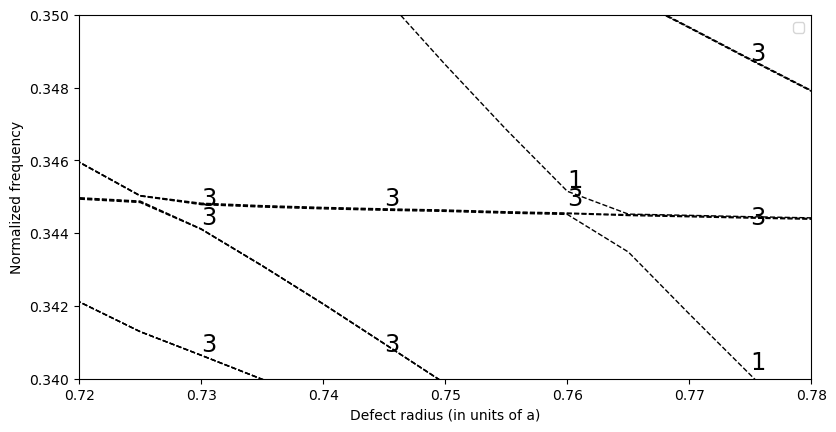

In [12]:
cm = 1/2.54
figure(figsize=(24*cm, 12*cm))
x_range = range(0.7, 0.8-0.1/20, 20)
plot(x_range, dispersions[1:20, :], linestyle="dashed", color="black", linewidth=1)
for (y_coord_idx, y_coord) in enumerate(y_coords)
    ((y_coord > 0.35) || (y_coord < 0.34)) && continue
    for (text_coord_idx, text_coord) in enumerate(1:3:20)
        horizonal_coordinate = x_range[text_coord]
        horizonal_coordinate  > 0.78 && continue
        horizonal_coordinate  < 0.72 && continue
        number_of_states = num_states[text_coord_idx][y_coord_idx]
        number_of_states == 0 && continue
        text(horizonal_coordinate, y_coord, number_of_states, size="xx-large")
    end
end
ylim(0.34, 0.35)

xlim(0.72, 0.78)
xlabel("Defect radius (in units of a)")
ylabel("Normalized frequency");
#savefig("defect_scan.pdf")
legend();

In [13]:
# zoom in from r/a = 0.75 to 0.77
dir = "./defect_scan/zoom_75to77/"
supercell = 5
resolution = 16
num_bands = 300
m = 20

dispersions = zeros((m, num_bands))
for n in 1:20
    filename = "supercell-$n-$m-$supercell-$resolution.log"
    io = open(dir * filename)
    logstr = read(io, String)
    close(io)
    dispersion_str = logs_to_dispersion(logstr, "");
    dispersion = readdlm(IOBuffer(dispersion_str), ',')[:, 6:end]
    dispersions[n, :] = dispersion
end

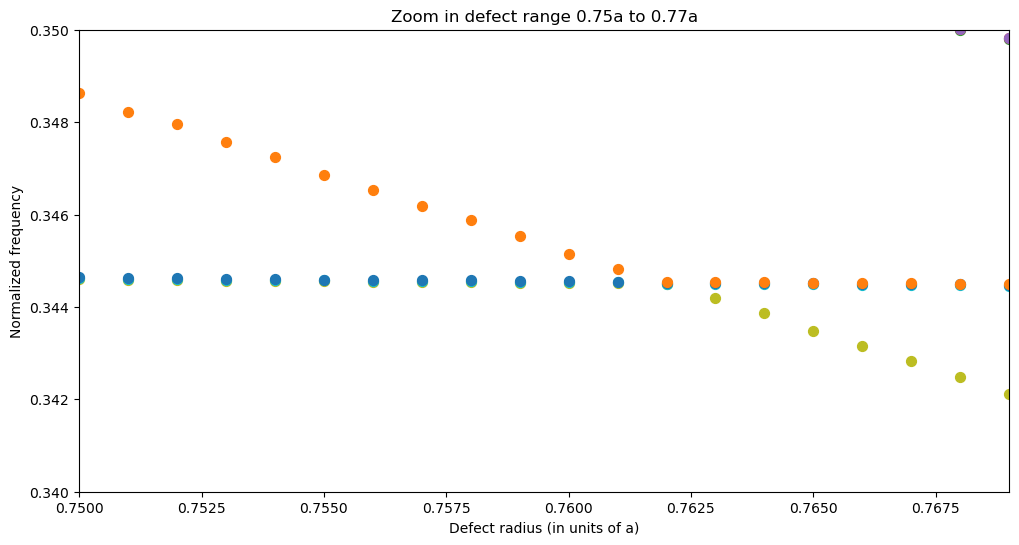

In [17]:
figure(figsize=(12, 6))
x_range = range(0.75, 0.77-0.02/20, 20)
for i in 1:300
    scatter(x_range, dispersions[1:20, i], s=50)#, linestyle="dashed", color="black", linewidth=3)
end
ylim(0.34, 0.35)
xlim(0.75,  0.77-0.02/20)
#xlim(0.76, 0.764)
xlabel("Defect radius (in units of a)")
ylabel("Normalized frequency")
title("Zoom in defect range 0.75a to 0.77a");
savefig("defect_scan_zoom_75_to_77.pdf")